In [4]:
import sys
sys.path.append('../')
sys.path.append('../plm_circuits')

# Import utility functions
from helpers.utils import (
    clear_memory,
    load_esm,
    load_sae_prot,
    mask_flanks_segment,
    patching_metric,
    cleanup_cuda,
    set_seed
)

# Import attribution functions
from attribution import (
    integrated_gradients_sae,
    topk_sae_err_pt
)

# Import hook classes
from hook_manager import SAEHookProt

from data.protein_params import sse_dict, fl_dict, protein_name, protein2pdb
from data.feature_clusters_hypotheses import feature_clusters_MetXA, feature_clusters_Top2

# Additional imports
import json
from functools import partial
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import collections
from typing import Dict, List, Tuple, Optional

In [5]:
# Setup device and load models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load ESM-2 model
esm_transformer, batch_converter, esm2_alphabet = load_esm(33, device=device)

# Load SAEs for multiple layers
main_layers = [4, 8, 12, 16, 20, 24, 28]
saes = []
for layer in main_layers:
    sae_model = load_sae_prot(ESM_DIM=1280, SAE_DIM=4096, LAYER=layer, device=device)
    saes.append(sae_model)

layer_2_saelayer = {layer: layer_idx for layer_idx, layer in enumerate(main_layers)}

print(f"Loaded SAEs for layers: {main_layers}")

# Load sequence data and define protein parameters
with open('../data/full_seq_dict.json', "r") as json_file:
    seq_dict = json.load(json_file)

# Choose protein for analysis
set_seed(0)

Using device: cuda
Loaded SAEs for layers: [4, 8, 12, 16, 20, 24, 28]


In [6]:
import requests
import pandas as pd
def fetch_uniprot_entry(acc: str) -> dict:
    url = f"https://rest.uniprot.org/uniprotkb/{acc}"
    r = requests.get(url, headers={"Accept": "application/json"}, timeout=20)
    r.raise_for_status()
    return r.json()

def fetch_uniprot_fasta(acc: str) -> str:
    url = f"https://rest.uniprot.org/uniprotkb/{acc}.fasta"
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    return r.text

def get_sae(layer: int):
    try:
        sae_model = load_sae_prot(ESM_DIM=1280, SAE_DIM=4096, LAYER=layer, device=get_device())  # predefined
    except NameError as e:
        raise RuntimeError("load_sae_prot(...) not found. Edit the import block near the top to point to your module.") from e
    return sae_model

def get_esm():
    # Uses your predefined loader
    try:
        esm_transformer, batch_converter, esm2_alphabet = load_esm(33, device=get_device())  # predefined
    except NameError as e:
        raise RuntimeError("load_esm(...) not found. Edit the import block near the top to point to your module.") from e
    return esm_transformer, batch_converter, esm2_alphabet

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_latent_activations_on_sequence(
    sequence: str,
    layer: int,
    latent_idx: int,
    use_masked_latents: bool = True,
    use_error: bool = False,
) -> np.ndarray:
    """Runs your SAE hook at the target layer and returns a 1D vector (length L) for the chosen latent."""
    esm_transformer, batch_converter, esm2_alphabet = get_esm()
    device = get_device()
    # tokenization
    _, _, batch_tokens_BL = batch_converter([(1, sequence)])
    batch_tokens_BL = batch_tokens_BL.to(device)
    batch_mask_BL = (batch_tokens_BL != esm2_alphabet.padding_idx).to(device)
    cache_latents = True
    if use_masked_latents:
        cache_latents = False
    # SAE hook
    sae_model = get_sae(layer)
    try:
        hook = SAEHookProt(
            sae=sae_model,
            mask_BL=batch_mask_BL,
            cache_latents=cache_latents,
            cache_masked_latents=use_masked_latents,
            layer_is_lm=False,
            calc_error=False,
            use_error=use_error,
        )
    except NameError as e:
        raise RuntimeError("SAEHookProt not found. Edit imports at the top to your module.") from e
    handle = esm_transformer.esm.encoder.layer[layer].register_forward_hook(hook)
    with torch.no_grad():
        _ = esm_transformer.predict_contacts(batch_tokens_BL, batch_mask_BL)[0]
    handle.remove()
    # choose source array
    arr = None
    if use_error and hasattr(sae_model, "error_term") and sae_model.error_term is not None:
        arr = sae_model.error_term  # shape [B, L, F]
        arr = np.asarray(arr)[0]  # [L, F]
        # print(f"error_term shape: {arr.shape}")
    elif use_masked_latents and hasattr(sae_model, "masked_latents") and sae_model.masked_latents is not None:
        arr = sae_model.masked_latents  # [L, F] or [B, L, F]
        # print(f"masked_latents shape: {arr.shape}")
    elif cache_latents and hasattr(sae_model, "feature_acts") and sae_model.feature_acts is not None:
        arr = sae_model.feature_acts  # [L, F] or [B, L, F]
        # print(f"feature_acts shape: {arr.shape}")
    # else:
    #     if use_masked_latents and hasattr(sae_model, "cache_masked_latents") and sae_model.cache_masked_latents is not None:
    #         arr = sae_model.cache_masked_latents  # [L, F] or [B, L, F]
    #     else:
    #         arr = sae_model.feature_acts  # [L, F] or [B, L, F]
    arr = np.asarray(arr.cpu())
    if arr.ndim == 3:
        arr = arr[0]
    L, F = arr.shape
    if not (0 <= latent_idx < F):
        raise ValueError(f"latent_idx {latent_idx} out of range [0, {F-1}]")
    return arr[:, latent_idx]

def fetch_interpro_protein(acc: str, page_size: int = 500) -> dict:
    # All database entries (Pfam + others) mapped to this UniProt accession
    # url = f"https://www.ebi.ac.uk/interpro/api/protein/uniprot/{acc}" https://www.ebi.ac.uk/interpro/api/entry/interpro/protein/uniprot/I1RF61
    url = f"https://www.ebi.ac.uk/interpro/api/entry/interpro/protein/uniprot/{acc}"
    r = requests.get(url, timeout=30) #r = requests.get(url, params={"page_size": page_size}, timeout=30)
    r.raise_for_status()
    return r.json()

def parse_interpro_domains(interpro_json: dict) -> pd.DataFrame:
    rows = []
    for rec in interpro_json.get("results", []):
        meta = rec.get("metadata", {}) or {}
        entry = meta.get("accession")
        name = meta.get("name")
        db = meta.get("source_database")

        # NEW schema: entry → proteins[] → entry_protein_locations[] → fragments[]
        if "proteins" in rec:
            for prot in rec.get("proteins") or []:
                for loc in prot.get("entry_protein_locations") or []:
                    for frag in loc.get("fragments") or []:
                        rows.append({
                            "entry": entry,
                            "name": name,
                            "db": db,
                            "start": int(frag.get("start")) if frag.get("start") is not None else None,
                            "end": int(frag.get("end")) if frag.get("end") is not None else None,
                        })
        # OLD schema fallback (if you ever switch back)
        else:
            for loc in rec.get("entry_protein_locations", []) or []:
                for frag in loc.get("fragments") or []:
                    rows.append({
                        "entry": entry,
                        "name": name,
                        "db": db,
                        "start": int(frag.get("start")) if frag.get("start") is not None else None,
                        "end": int(frag.get("end")) if frag.get("end") is not None else None,
                    })

    if not rows:
        return pd.DataFrame(columns=["entry", "name", "db", "start", "end"])
    df = pd.DataFrame(rows).sort_values(["start", "end"]).reset_index(drop=True)
    return df


In [128]:
import helpers.protein_viz_utils as viz
def render_sequence_heatmap(
    seq: str,
    values: np.ndarray,
    colormap_fn=viz.mono_colormap_fn,
    wrap: int = 120,  # ignored (kept for API compatibility)
    vmin: float | None = None,
    vmax: float | None = None,
    height: int | None = None,
    title: str = "Sequence heatmap",
):
    import html, uuid
    from IPython.display import HTML
    
    L = len(seq) if seq else 0
    if values is None or L == 0:
        print("No sequence/activations to render.")
        return
    vmin = float(np.min(values)) if vmin is None else float(vmin)
    vmax = float(np.max(values)) if vmax is None else float(vmax)

    # Unique id so multiple boxes don't clash across reruns
    uid = f"seqbox-{uuid.uuid4().hex[:8]}"

    spans = []
    for i, (aa, val) in enumerate(zip(seq, values)):
        color = colormap_fn(float(val), vmin, vmax)
        aa_esc = html.escape(aa)
        # data-* attrs let JS show an index+value tooltip
        spans.append(
            f'<span class="res" data-i="{i}" data-val="{float(val):.6f}" '
            f'style="background:{color}">{aa_esc}</span>'
        )

    rows_html = "".join(spans)
    # Single-row strip, fixed compact height
    h = height if height is not None else 82

    html_block = f'''
    <div id="{uid}" class="seqbox">
      <div class="title">{html.escape(title)}</div>
      <div class="strip">{rows_html}</div>
      <div class="tip" style="display:none;"></div>
    </div>
    <style>
    #{uid}.seqbox {{
        overflow-x: auto; overflow-y: hidden;
        border: 1px solid #eee; border-radius: 8px; padding: 6px 8px;
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, "Liberation Mono", monospace;
        background: #fff;
    }}
    #{uid} .title {{ font-size: 0.9rem; color: #444; margin-bottom: 6px; white-space: nowrap; }}
    #{uid} .strip {{
        white-space: nowrap;
    }}
    #{uid} .strip .res {{
        display:inline-block; margin:0 1px 0 0; padding:1px 2px; border-radius:3px;
        color:#111; line-height:1.3rem; font-size:0.95rem; cursor:default;
    }}
    #{uid} .strip .res:hover {{
        outline: 1px solid rgba(0,0,0,0.25);
    }}
    #{uid} .tip {{
        position: fixed; z-index: 9999;
        background: rgba(0,0,0,0.85); color: #fff; padding: 4px 6px;
        border-radius: 4px; font-size: 12px; pointer-events: none;
        box-shadow: 0 2px 6px rgba(0,0,0,0.25);
    }}
    </style>
    <script>
    (function() {{
        const root = document.getElementById("{uid}");
        if (!root) return;
        const tip = root.querySelector(".tip");
        const strip = root.querySelector(".strip");
        const show = (x, y, text) => {{
            tip.style.display = "block";
            tip.style.left = (x + 12) + "px";
            tip.style.top  = (y + 12) + "px";
            tip.textContent = text;
        }};
        const hide = () => {{ tip.style.display = "none"; }};
        strip.addEventListener("mousemove", (e) => {{
            const t = e.target;
            if (t && t.classList && t.classList.contains("res")) {{
                const i = t.getAttribute("data-i");
                const v = Number(t.getAttribute("data-val")).toFixed(3);
                show(e.clientX, e.clientY, i + ": " + v);
            }} else {{
                hide();
            }}
        }});
        strip.addEventListener("mouseleave", hide);
    }})();
    </script>
    '''
    return HTML(html_block)

def draw_sequence_tracks(
    L: int,
    domains_df: pd.DataFrame,
    activations: Optional[np.ndarray] = None,
    coverage_segments: Optional[List[Tuple[int, int]]] = None,
    title: str = "Sequence tracks",
    sequence_letters: Optional[str] = None,
    show_bars_when_activations: bool = True,
    coverage_prefix: int = 0,
):
    import matplotlib.pyplot as plt
    import matplotlib.patheffects as pe

    # Greedy lane assignment to avoid overlapping rectangles
    intervals = []  # (idx, start, end, label)
    if domains_df is not None and len(domains_df) > 0:
        for idx, r in domains_df.iterrows():
            try:
                s, e = int(r.start), int(r.end)
            except Exception:
                continue
            if pd.isna(s) or pd.isna(e):
                continue
            label = r.get("name") or r.get("entry") or ""
            intervals.append((idx, int(s), int(e), str(label)))

    intervals_sorted = sorted(intervals, key=lambda x: (x[1], x[2]))
    lane_end_positions: List[int] = []
    row_to_lane: Dict[int, int] = {}
    for idx, s, e, _ in intervals_sorted:
        placed = False
        for lane_idx, last_end in enumerate(lane_end_positions):
            # Non-overlap if current start is strictly greater than last end (inclusive ranges)
            if s > last_end:
                row_to_lane[idx] = lane_idx
                lane_end_positions[lane_idx] = e
                placed = True
                break
        if not placed:
            row_to_lane[idx] = len(lane_end_positions)
            lane_end_positions.append(e)

    num_lanes = max(row_to_lane.values()) + 1 if row_to_lane else 1

    # Layout scaling - make rectangles very small and stack them
    rect_height = 0.08  # Very small height for each domain rectangle
    lane_spacing = 0.12  # Small spacing between lanes
    domains_section_height = max(0.5, num_lanes * lane_spacing)  # Minimum 0.5, scales with lanes
    
    # Dynamic plot height calculation
    base_h = 2.5 if activations is None else 4.5
    extra_h = max(0, domains_section_height - 0.5)  # Extra height for domains beyond base
    fig, ax = plt.subplots(figsize=(12, base_h + extra_h))

    # Draw main sequence line at the bottom of domains section
    sequence_line_y = domains_section_height - 0.1
    ax.plot([1, L], [sequence_line_y, sequence_line_y], lw=4, alpha=0.2, color='gray')
    
    # Draw stacked domain rectangles
    for idx, r in domains_df.iterrows():
        if pd.isna(r.start) or pd.isna(r.end):
            continue
        s, e = int(r.start)+coverage_prefix, int(r.end)+coverage_prefix
        
        # Get lane for this domain and calculate y position
        lane = row_to_lane.get(idx, 0)
        rect_y = lane * lane_spacing
        
        # Draw small rectangle in assigned lane
        ax.add_patch(
            plt.Rectangle((s, rect_y), max(1, e - s + 1), rect_height, alpha=0.6)
        )
        
        # Position label inside the rectangle center
        label_y = rect_y + rect_height / 2
        txt = str(r.get("name") or r.get("entry") or "")
        
        # Truncate overly long labels roughly to fit the rectangle span
        try:
            span = max(1, e - s + 1)
            max_chars = int(max(6, min(30, span * 0.3)))
        except Exception:
            max_chars = 20
        try:
            disp_txt = textwrap.shorten(txt, width=max_chars, placeholder="…")
        except Exception:
            disp_txt = txt
            
        ax.text(
            (s + e) / 2,
            label_y,
            disp_txt,
            ha="center",
            va="center",
            fontsize=7,
            clip_on=False,
            # path_effects=[pe.withStroke(linewidth=1.5, foreground="white")],
            color='black',
            weight='bold',
            alpha=0.5
        )
    
    # Draw coverage segments at the very bottom
    if coverage_segments:
        for s, e in coverage_segments:
            ax.add_patch(plt.Rectangle((s, -0.05), max(1, e - s + 1), 0.03, color='red', alpha=0.7))
    
    ax.set_xlim(1, L)
    ax.set_ylim(-0.1, domains_section_height + (0.8 if activations is not None else 0.2))
    ax.set_yticks([])
    
    # Handle activations on separate axis
    if activations is not None:
        xs = np.arange(1, L + 1)
        if show_bars_when_activations:
            # Draw bars on a twin axis, optionally label with letters
            ax2 = ax.twinx()
            vals = np.asarray(activations, dtype=float)
            # Align values length to L
            if vals.shape[0] > L:
                vals = vals[:L]
            elif vals.shape[0] < L:
                pad = np.full(L - vals.shape[0], np.nan, dtype=float)
                vals = np.concatenate([vals, pad], axis=0)
            # Normalize letters length to L if provided
            seq_letters = sequence_letters
            if seq_letters is not None:
                if len(seq_letters) < L:
                    seq_letters = seq_letters + ("X" * (L - len(seq_letters)))
                elif len(seq_letters) > L:
                    seq_letters = seq_letters[:L]
            colors = None
            if seq_letters is not None:
                uniq = sorted(set(seq_letters))
                color_map = {aa: f"C{i % 10}" for i, aa in enumerate(uniq)}
                colors = [color_map.get(aa, "C0") for aa in seq_letters]
            ax2.bar(xs, vals, color=colors, width=0.8, alpha=0.9)
            if seq_letters is not None:
                for x, aa, v in zip(xs, seq_letters, vals):
                    va = "bottom" if (np.isnan(v) or v >= 0) else "top"
                    offset = 0.01 if (np.isnan(v) or v >= 0) else -0.01
                    if v > 0:
                        ax2.text(x, (0.0 if np.isnan(v) else v) + offset, aa, ha="center", va=va, fontsize=7)
            ax2.set_ylabel("Activation")
            ax2.grid(True, axis="y", alpha=0.2)
        else:
            ax2 = ax.twinx()
            ax2.plot(xs, activations, lw=1)
            ax2.set_ylabel("Activation")
            ax2.grid(True, alpha=0.2)
    ax.set_title(title)
    plt.show()

def draw_uniprot_features(
    L: int,
    features_list: List[Dict],
    activations: Optional[np.ndarray] = None,
    title: str = "UniProt Features",
    sequence_letters: Optional[str] = None,
    show_bars_when_activations: bool = True,
    coverage_prefix: int = 0,
):
    import matplotlib.pyplot as plt
    import matplotlib.patheffects as pe
    from matplotlib.patches import Patch
    import textwrap
    
    # Extract intervals from UniProt features format
    intervals = []  # (idx, start, end, label, feature_type)
    for idx, feature in enumerate(features_list):
        try:
            # Extract start and end from nested location structure
            start_val = feature['location']['start']['value']
            end_val = feature['location']['end']['value']
            s, e = int(start_val), int(end_val)
        except (KeyError, ValueError, TypeError):
            continue
            
        # Get feature type and description
        feature_type = feature.get('type', '')
        description = feature.get('description', '')
        
        # Use description as the label, fallback to feature_type
        label = description if description else feature_type
            
        intervals.append((idx, s, e, str(label), feature_type))

    # Greedy lane assignment to avoid overlapping rectangles
    intervals_sorted = sorted(intervals, key=lambda x: (x[1], x[2]))
    lane_end_positions: List[int] = []
    row_to_lane: Dict[int, int] = {}
    
    for idx, s, e, _, _ in intervals_sorted:
        placed = False
        for lane_idx, last_end in enumerate(lane_end_positions):
            # Non-overlap if current start is strictly greater than last end
            if s > last_end:
                row_to_lane[idx] = lane_idx
                lane_end_positions[lane_idx] = e 
                placed = True
                break
        if not placed:
            row_to_lane[idx] = len(lane_end_positions)
            lane_end_positions.append(e)

    num_lanes = max(row_to_lane.values()) + 1 if row_to_lane else 1

    # Layout scaling - make rectangles very small and stack them
    rect_height = 0.08  # Very small height for each feature rectangle
    lane_spacing = 0.12  # Small spacing between lanes
    features_section_height = max(0.5, num_lanes * lane_spacing)  # Minimum 0.5, scales with lanes
    
    # Dynamic plot height calculation
    base_h = 2.5 if activations is None else 4.5
    extra_h = max(0, features_section_height - 0.5)  # Extra height for features beyond base
    fig, ax = plt.subplots(figsize=(14, base_h + extra_h))  # Wider to accommodate legends

    # Draw main sequence line at the bottom of features section
    sequence_line_y = features_section_height - 0.1
    ax.plot([1, L], [sequence_line_y, sequence_line_y], lw=4, alpha=0.2, color='gray')
    
    # Color map for different feature types
    feature_types = sorted(list(set([f[4] for f in intervals])))  # Sort for consistent legend order
    color_map = {ftype: f"C{i % 10}" for i, ftype in enumerate(feature_types)}
    
    # Draw stacked feature rectangles with description labels on top
    for idx, s, e, label, feature_type in intervals:
        # Get lane for this feature and calculate y position
        lane = row_to_lane.get(idx, 0)
        rect_y = lane * lane_spacing
        s, e = s+coverage_prefix, e+coverage_prefix
        # Get color based on feature type
        rect_color = color_map.get(feature_type, 'C0')
        
        # Draw small rectangle in assigned lane
        ax.add_patch(
            plt.Rectangle((s, rect_y), max(1, e - s + 1), rect_height, 
                         alpha=0.5, color=rect_color)
        )
        
        # Add description text above the rectangle
        label_y = rect_y + 0.01  # Position above the rectangle
        
        # Truncate overly long labels to fit the rectangle span
        try:
            span = max(1, e - s + 1)
            max_chars = int(max(10, min(50, span * 0.75)))
        except Exception:
            max_chars = 15
        try:
            disp_txt = textwrap.shorten(label, width=max_chars, placeholder="")
        except Exception:
            disp_txt = label
            
        # Only show text if rectangle is wide enough
        if e - s + 1 >= 8:  # Only show text for rectangles >= 8 units wide
            ax.text(
                (s + e) / 2,
                label_y,
                disp_txt,
                ha="center",
                va="bottom",
                fontsize=9,
                clip_on=False,
                path_effects=[pe.withStroke(linewidth=1, foreground="white")],
                color='black',
                weight='bold',
                alpha=0.5
            )
        else:
            x_center = (s + e) / 2
            # Keep the label within the x-limits; nudge to the right of the feature
            x_text = min(L - 0.5, e + 2)
            y_text = rect_y + rect_height + 0.04
            ax.annotate(
                disp_txt,
                xy=(x_center, rect_y + rect_height / 2),
                xytext=(x_text, y_text),
                textcoords="data",
                ha="left",
                va="bottom",
                fontsize=9,
                color='black',
                alpha=0.8,
                path_effects=[pe.withStroke(linewidth=1, foreground="white")],
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, shrinkA=0, shrinkB=0),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=0.5),
                clip_on=False,
            )
    ax.set_xlim(1, L)
    ax.set_ylim(-0.1, features_section_height + (0.8 if activations is not None else 0.2))
    ax.set_yticks([])
    
    # Create legend for feature types only
    if feature_types:
        legend_elements = [Patch(facecolor=color_map[ftype], alpha=0.7, label=ftype) 
                          for ftype in feature_types]
        legend1 = ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1), 
                           title="Feature Types", fontsize=9, title_fontsize=10)
        ax.add_artist(legend1)
    
    # Handle activations on separate axis
    ax2 = None
    if activations is not None:
        xs = np.arange(1, L + 1)
        if show_bars_when_activations:
            # Draw bars on a twin axis, optionally label with letters
            ax2 = ax.twinx()
            vals = np.asarray(activations, dtype=float)
            # Align values length to L
            if vals.shape[0] > L:
                vals = vals[:L]
            elif vals.shape[0] < L:
                pad = np.full(L - vals.shape[0], np.nan, dtype=float)
                vals = np.concatenate([vals, pad], axis=0)
            # Normalize letters length to L if provided
            seq_letters = sequence_letters
            if seq_letters is not None:
                if len(seq_letters) < L:
                    seq_letters = seq_letters + ("X" * (L - len(seq_letters)))
                elif len(seq_letters) > L:
                    seq_letters = seq_letters[:L]
            colors = None
            if seq_letters is not None:
                uniq = sorted(set(seq_letters))
                color_map_seq = {aa: f"C{i % 10}" for i, aa in enumerate(uniq)}
                colors = [color_map_seq.get(aa, "C0") for aa in seq_letters]
            ax2.bar(xs, vals, color=colors, width=0.8, alpha=0.9)
            if seq_letters is not None:
                for x, aa, v in zip(xs, seq_letters, vals):
                    va = "bottom" if (np.isnan(v) or v >= 0) else "top"
                    offset = 0.01 if (np.isnan(v) or v >= 0) else -0.01
                    if v > 0:
                        ax2.text(x, (0.0 if np.isnan(v) else v) + offset, aa, ha="center", va=va, fontsize=7)
            ax2.set_ylabel("Activation")
            ax2.grid(True, axis="y", alpha=0.2)
        else:
            ax2 = ax.twinx()
            ax2.plot(xs, activations, lw=1)
            ax2.set_ylabel("Activation")
            ax2.grid(True, alpha=0.2)
    
    ax.set_title(title)
    plt.tight_layout()  # Better layout management
    plt.show()

    

In [ ]:
import time, random, requests
from typing import Iterable, List, Tuple, Optional

BASE = "https://www.ebi.ac.uk/interpro/api"

def _infer_db_and_acc(identifier: str, db: Optional[str] = None) -> Tuple[str, str]:
    """Infer InterPro member DB from the identifier if not provided."""
    if db:
        return db.lower(), identifier
    x = identifier.upper()
    if x.startswith("PF"):      # Pfam family
        return "pfam", x
    if x.startswith("IPR"):     # InterPro integrated entry
        return "interpro", x
    if x.startswith("G3DSA"):   # CATH-Gene3D superfamily
        return "cathgene3d", identifier
    if x.startswith("SSF"):     # SUPERFAMILY (SCOP-derived)
        return "ssf", x
    raise ValueError("Couldn't infer database; pass db= one of {'pfam','interpro','cathgene3d','ssf'}.")

def _get_json(url: str, *, max_tries: int = 6, backoff: float = 0.8):
    """GET with polite retries for 202/5xx (InterPro often warms caches)."""
    for i in range(max_tries):
        r = requests.get(url, timeout=60)
        if r.status_code == 200:
            return r.json()
        # InterPro may return 202 Accepted or transient 5xx while caching
        if r.status_code in (202, 502, 503, 504):
            time.sleep(backoff * (2 ** i) + random.random() * 0.2)
            continue
        r.raise_for_status()
    raise RuntimeError(f"InterPro API not ready after {max_tries} tries: {url}")

def iter_reviewed_proteins_by_entry(db: str, acc: str, page_size: int = 200, max_pages: int = 10) -> Iterable[dict]:
    """
    Yield protein records (JSON 'metadata' blocks) for reviewed UniProt proteins
    matching an entry (Pfam/IPR/CATH-Gene3D/SUPERFAMILY).
    """
    url = f"{BASE}/protein/reviewed/entry/{db}/{requests.utils.quote(acc, safe='')}/?page_size={page_size}"
    pages = 0
    while url and pages < max_pages:
        data = _get_json(url)
        for row in data.get("results", []):
            yield row.get("metadata", row)
        url = data.get("next")
        pages += 1

def sample_uniprot_ids(
    identifier: str,
    n: int = 50,
    db: Optional[str] = None,
    page_size: int = 200,
    max_pages: int = 10,
    seed: Optional[int] = None,
) -> List[str]:
    """
    Return up to n reviewed UniProt accessions for proteins containing the entry.
    Sampling is reservoir-style over up to `max_pages` pages for speed.
    """
    if seed is not None:
        random.seed(seed)
    db, acc = _infer_db_and_acc(identifier, db)

    reservoir: List[str] = []
    seen = 0
    for meta in iter_reviewed_proteins_by_entry(db, acc, page_size=page_size, max_pages=max_pages):
        up = meta.get("accession") or meta.get("acc")  # defensive
        if not up:
            continue
        seen += 1
        if len(reservoir) < n:
            reservoir.append(up)
        else:
            j = random.randint(0, seen - 1)
            if j < n:
                reservoir[j] = up

    return reservoir

# -------------------------
# EXAMPLES
# -------------------------

print(sample_uniprot_ids("PF00069", n=5, seed=42))

# # InterPro integrated entry (e.g., P-loop NTPase)
# print(sample_uniprot_ids("IPR027417", n=5, seed=1))

# # CATH-Gene3D homologous superfamily
# print(sample_uniprot_ids("G3DSA:3.30.70.100", n=5))

# # SUPERFAMILY (SCOP-based) superfamily
# print(sample_uniprot_ids("SSF52540", n=5))

In [ ]:
import random, requests
from urllib.parse import quote

# ---------- OPTION A: UniProt (fastest) ----------
# Works for Pfam (PFxxxxx) and InterPro (IPRxxxxx)
def uniprot_reviewed_ids(identifier: str, n: int = 50, oversample_factor: int = 4):
    """Return up to n Swiss-Prot accessions that cross-reference the given Pfam/IPR."""
    x = identifier.upper()
    if   x.startswith("PF"): q = f"(xref:pfam:{x}) AND (reviewed:true)"
    elif x.startswith("IPR"): q = f"(xref:interpro:{x}) AND (reviewed:true)"
    else: raise ValueError("Use a Pfam (PF...) or InterPro (IPR...) accession for UniProt mode.")

    size = max(n, min(n * oversample_factor, 500))  # fetch a single small page, then sample
    url = (
        "https://rest.uniprot.org/uniprotkb/search"
        f"?query={quote(q)}&fields=accession&format=tsv&size={size}"
    )
    r = requests.get(url, timeout=30, headers={"Accept": "text/tab-separated-values"})
    r.raise_for_status()
    lines = r.text.strip().splitlines()
    if len(lines) <= 1:
        return []
    accs = [ln.split("\t", 1)[0] for ln in lines[1:]]  # first column is accession
    random.shuffle(accs)  # light randomization (no seed)
    return accs[:n]


# ---------- OPTION B: InterPro (fast + stays in InterPro) ----------
# Also supports Pfam (PF...), InterPro (IPR...), CATH-Gene3D (G3DSA:...), SUPERFAMILY (SSF...)
def interpro_reviewed_ids_fast(identifier: str, n: int = 50, oversample_factor: int = 4):
    """TSV, single (oversized) page, then sample locally. Much faster than JSON + pagination."""
    x = identifier.upper()
    if   x.startswith("PF"):   db, acc = "pfam", x
    elif x.startswith("IPR"):  db, acc = "interpro", x
    elif x.startswith("G3DSA"): db, acc = "cathgene3d", identifier  # keep case
    elif x.startswith("SSF"):  db, acc = "ssf", x
    else:
        raise ValueError("Unrecognized id. Use PF..., IPR..., G3DSA:..., or SSF...")

    size = max(n, min(n * oversample_factor, 500))  # one page
    url = (
        "https://www.ebi.ac.uk/interpro/api/protein/reviewed"
        f"/entry/{db}/{quote(acc, safe='')}/?page_size={size}&format=tsv"
    )
    r = requests.get(url, timeout=60, headers={"Accept": "text/tab-separated-values"})
    # InterPro can occasionally be warming caches; if you see 202/408 intermittently, just retry once or twice.
    r.raise_for_status()
    lines = r.text.strip().splitlines()
    if not lines:
        return []
    # Find the "Accession" column (safer than hardcoding idx)
    header = lines[0].split("\t")
    try:
        i = header.index("Accession")
    except ValueError:
        i = 0  # fall back to first column
    accs = [ln.split("\t")[i] for ln in lines[1:] if ln]
    random.shuffle(accs)
    return accs[:n]

import requests, time, random

def _get_json(url, tries=4, base_delay=0.6):
    # InterPro sometimes returns 202 while warming cache
    for i in range(tries):
        r = requests.get(url, headers={"Accept": "application/json"}, timeout=20)
        if r.status_code == 200:
            return r.json()
        if r.status_code in (202, 502, 503, 504):
            time.sleep(base_delay * (2**i) + random.random()*0.2)
            continue
        r.raise_for_status()
    raise RuntimeError(f"InterPro not ready after {tries} tries: {url}")

def interpro_entry_meta(ipr_id: str):
    """
    Return {'name', 'short_name', 'type', 'accession'} for an InterPro ID.
    Uses JSON (not TSV) and is robust to minor schema differences.
    """
    ipr_id = ipr_id.strip().upper()
    url = f"https://www.ebi.ac.uk/interpro/api/entry/interpro/{ipr_id}/"
    data = _get_json(url)

    # Some responses are the object itself; others wrap in 'metadata'
    meta = data.get("metadata", data) if isinstance(data, dict) else {}

    # 'name' can be a string or an object with {'name', 'short'}
    name = meta.get("name")
    short_name = meta.get("short_name")
    if isinstance(name, dict):
        short_name = short_name or name.get("short") or name.get("short_name")
        name = name.get("name") or name.get("value") or name.get("full")

    # Defensive clean-up in case the server echoes the accession as “name”
    if name and name.strip('"\'' ).upper() == ipr_id:
        name = None  # fall back to None if it’s not a real name

    return {
        "accession": meta.get("accession") or ipr_id,
        "name": name,
        "short_name": short_name,
        "type": meta.get("type"),
    }

# Example
# if __name__ == "__main__":
# print(interpro_entry_meta("IPR029063"))

{'accession': 'IPR029063', 'name': 'S-adenosyl-L-methionine-dependent methyltransferase superfamily', 'short_name': 'SAM-dependent_MTases_sf', 'type': 'homologous_superfamily'}


In [164]:
class_id = "IPR001557"
class_meta = interpro_entry_meta(class_id)

In [165]:
sample_uniprot_ids(class_id, n=2, seed=42)

['Q2J3G8', 'Q1WSG2']

In [172]:
uniprot_acc = "Q1WSG2" # sample_uniprot_ids(class_id, n=1, seed=42)[-1] # uni_ids[0] #"P45131" 
selected_layer = 8
latent_idx = 2677
print(f"Analyzing protein: {uniprot_acc}")
print(f"InterPro class: {class_meta['name']}")

Analyzing protein: Q1WSG2
InterPro class: L-lactate/malate dehydrogenase


In [ ]:
# uniprot_meta = fetch_uniprot_entry(uniprot_acc)
fasta = fetch_uniprot_fasta(uniprot_acc)
lines = [ln for ln in fasta.splitlines() if ln and not ln.startswith(">")]
uniprot_seq = "".join(lines).strip()
uniprot_meta = fetch_uniprot_entry(uniprot_acc)
interpro_json = fetch_interpro_protein(uniprot_acc)
interpro_df = parse_interpro_domains(interpro_json)
interpro_df.head(30)

,entry,name,db,start,end
0,IPR036291,NAD(P)-binding domain superfamily,interpro,4,148
1,IPR001557,L-lactate/malate dehydrogenase,interpro,4,321
2,IPR011304,L-lactate dehydrogenase,interpro,7,315
3,IPR001236,"Lactate/malate dehydrogenase, N-terminal",interpro,9,146
4,IPR015955,"Lactate dehydrogenase/glycoside hydrolase, fam...",interpro,147,314
5,IPR022383,"Lactate/malate dehydrogenase, C-terminal",interpro,149,316
6,IPR018177,"L-lactate dehydrogenase, active site",interpro,177,183


In [174]:
computed_act = compute_latent_activations_on_sequence(
                    sequence=uniprot_seq,
                    layer=selected_layer,
                    latent_idx=int(latent_idx),
                    use_masked_latents=True,
                    use_error=False,
                )
print(computed_act.shape)
render_sequence_heatmap(uniprot_seq, computed_act[1:-1])

(324,)


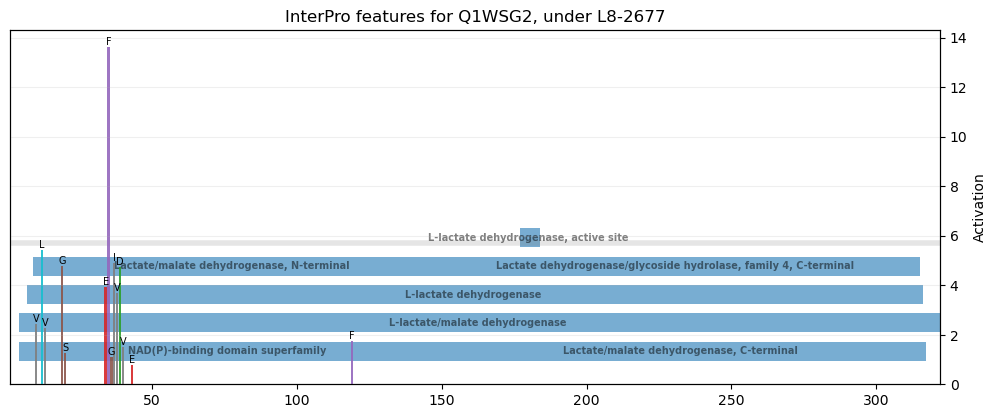

In [175]:
draw_sequence_tracks(len(uniprot_seq), interpro_df, activations=computed_act[1:-1], sequence_letters=uniprot_seq, title=f"InterPro features for {uniprot_acc}, under L{selected_layer}-{latent_idx}")

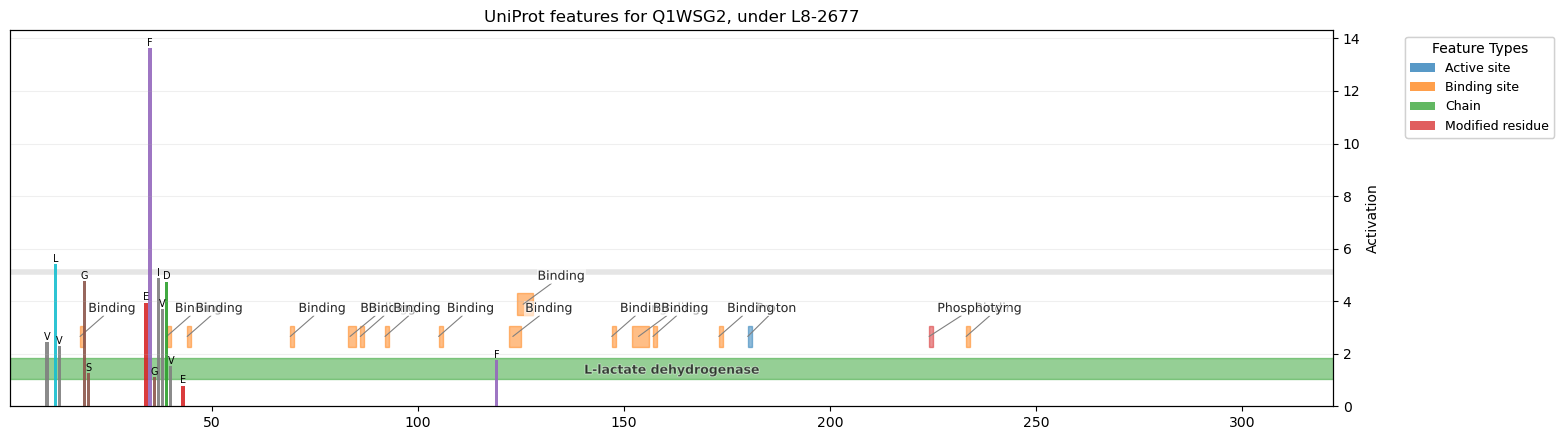

In [176]:
draw_uniprot_features(len(uniprot_seq), uniprot_meta["features"], activations=computed_act[1:-1], sequence_letters=uniprot_seq, title=f"UniProt features for {uniprot_acc}, under L{selected_layer}-{latent_idx}")

In [177]:
print(uniprot_acc)
from IPython.display import HTML
v = viz.view_single_protein(
                        uniprot_id=uniprot_acc,
                        chain_id="A",
                        values_to_color=computed_act[1:-1].tolist(),
                        colormap_fn=viz.mono_colormap_fn, #rwb_colormap_fn,
                        default_color="white",
                        pymol_params={"width": 700, "height": 520},
                    )
html = v._make_html()
HTML(html)

Q1WSG2
Structure has 322 residues in chain A.


# Masked pred setup

In [13]:
from data.protein_params import sse_dict, fl_dict, protein_name, protein2pdb
with open('../data/full_seq_dict.json', "r") as json_file:
    seq_dict = json.load(json_file)

In [14]:
protein = "MetXA" # "MetXA" or "Top2"

# pdb reference 
pdb_id = protein2pdb[protein]
seq = seq_dict[pdb_id]
position = sse_dict[pdb_id][0]

print(f"Analyzing protein: {protein} {pdb_id}")
print(f"Sequence length: {len(seq)}")

# Define segment boundaries
ss1_start = position[0] - 5 
ss1_end = position[0] + 5 + 1 
ss2_start = position[1] - 5 
ss2_end = position[1] + 5 + 1 
# Prepare sequences and get baseline contact predictions
full_seq_L = [(1, seq)]
_, _, batch_tokens_BL = batch_converter(full_seq_L)
batch_tokens_BL = batch_tokens_BL.to(device)
batch_mask_BL = (batch_tokens_BL != esm2_alphabet.padding_idx).to(device)

with torch.no_grad():
    full_seq_contact_LL = esm_transformer.predict_contacts(batch_tokens_BL, batch_mask_BL)[0]

# Prepare clean sequence (with optimal flanks)
clean_fl = fl_dict[pdb_id][0]
L = len(seq)
left_start = max(0, ss1_start - clean_fl)
left_end = ss1_start
right_start = ss2_end
right_end = min(L, ss2_end + clean_fl)
unmask_left_idxs = list(range(left_start, left_end))
unmask_right_idxs = list(range(right_start, right_end))

clean_seq_L = mask_flanks_segment(seq, ss1_start, ss1_end, ss2_start, ss2_end, unmask_left_idxs, unmask_right_idxs)
_, _, clean_batch_tokens_BL = batch_converter([(1, clean_seq_L)])
clean_batch_tokens_BL = clean_batch_tokens_BL.to(device)
clean_batch_mask_BL = (clean_batch_tokens_BL != esm2_alphabet.padding_idx).to(device)

with torch.no_grad():
    clean_seq_contact_LL = esm_transformer.predict_contacts(clean_batch_tokens_BL, clean_batch_mask_BL)[0]

# Prepare corrupted sequence (with suboptimal flanks)
corr_fl = fl_dict[pdb_id][1]
left_start = max(0, ss1_start - corr_fl)
left_end = ss1_start
right_start = ss2_end
right_end = min(L, ss2_end + corr_fl)
unmask_left_idxs = list(range(left_start, left_end))
unmask_right_idxs = list(range(right_start, right_end))

corr_seq_L = mask_flanks_segment(seq, ss1_start, ss1_end, ss2_start, ss2_end, unmask_left_idxs, unmask_right_idxs)
_, _, corr_batch_tokens_BL = batch_converter([(1, corr_seq_L)])
corr_batch_tokens_BL = corr_batch_tokens_BL.to(device)
corr_batch_mask_BL = (corr_batch_tokens_BL != esm2_alphabet.padding_idx).to(device)

with torch.no_grad():
    corr_seq_contact_LL = esm_transformer.predict_contacts(corr_batch_tokens_BL, corr_batch_mask_BL)[0]

# Create patching metric function
_patching_metric = partial(
    patching_metric,
    orig_contact=full_seq_contact_LL,
    ss1_start=ss1_start,
    ss1_end=ss1_end,
    ss2_start=ss2_start,
    ss2_end=ss2_end,
)

baseline_recovery = _patching_metric(clean_seq_contact_LL)
corrupted_recovery = _patching_metric(corr_seq_contact_LL)

print(f"Baseline contact recovery: {baseline_recovery:.4f}")
print(f"Corrupted contact recovery: {corrupted_recovery:.4f}")

Analyzing protein: MetXA 2B61A
Sequence length: 377
Baseline contact recovery: 0.5738
Corrupted contact recovery: 0.0279


In [15]:
computed_act_clean = compute_latent_activations_on_sequence(
                    sequence=clean_seq_L,
                    layer=selected_layer,
                    latent_idx=int(latent_idx),
                    use_masked_latents=True,
                    use_error=False,
                )
computed_act_corr = compute_latent_activations_on_sequence(
                    sequence=corr_seq_L,
                    layer=selected_layer,
                    latent_idx=int(latent_idx),
                    use_masked_latents=True,
                    use_error=False,
                )
computed_act_full = compute_latent_activations_on_sequence(
                    sequence=seq,
                    layer=selected_layer,
                    latent_idx=int(latent_idx),
                    use_masked_latents=True,
                    use_error=False,
                )
print(computed_act_clean.shape)
print(computed_act_corr.shape)
print(computed_act_full.shape)

(379,)
(379,)
(379,)


In [16]:
len(seq) - len(uniprot_seq)

19

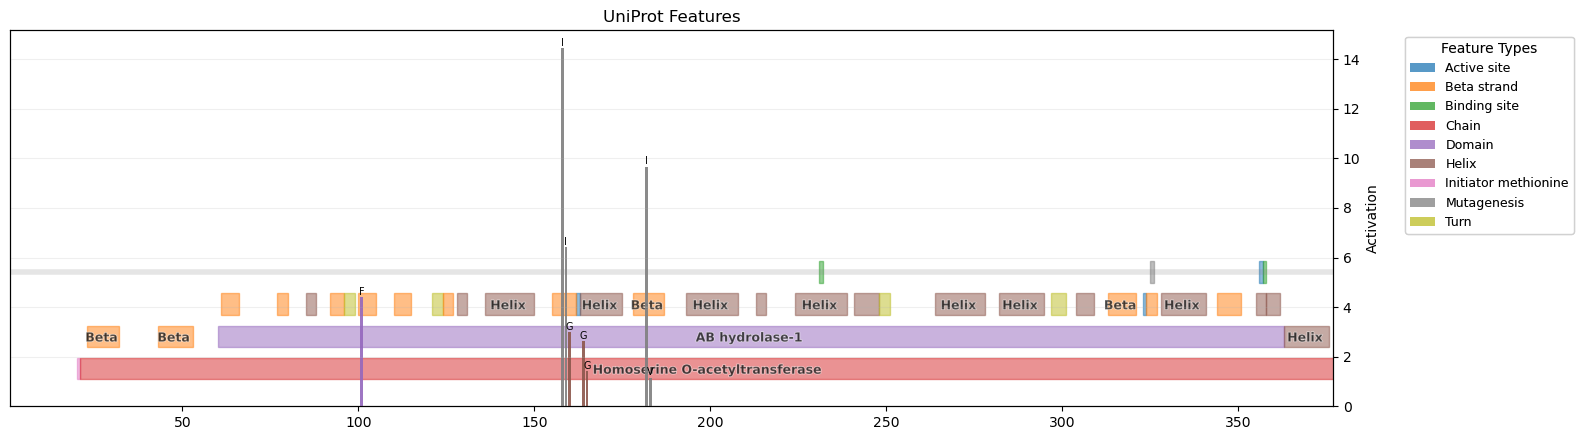

In [18]:
draw_uniprot_features(len(seq), uniprot_meta["features"], activations=computed_act_full[1:-1], sequence_letters=seq, coverage_prefix=len(seq) - len(uniprot_seq)) 

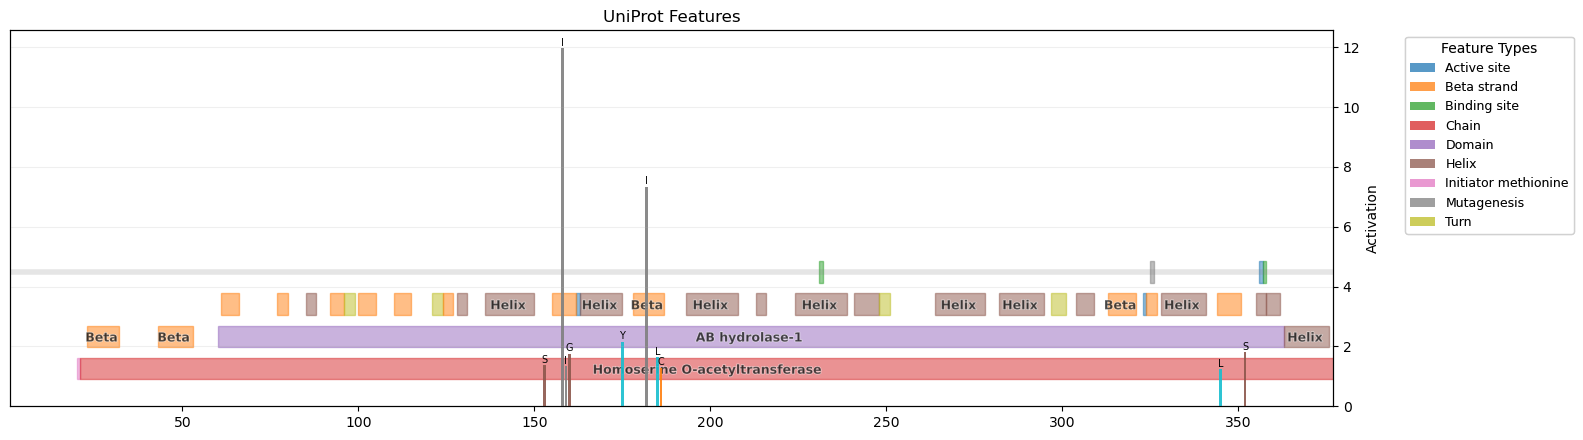

In [19]:
draw_uniprot_features(len(seq), uniprot_meta["features"], activations=computed_act_clean[1:-1], sequence_letters=seq, coverage_prefix=len(seq) - len(uniprot_seq)) 

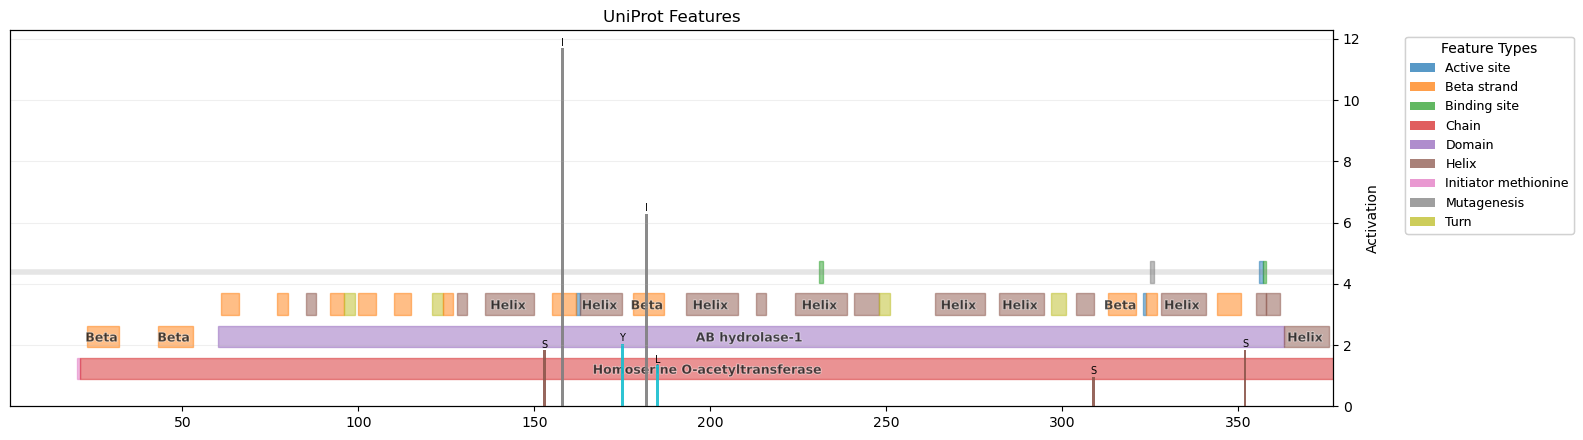

In [20]:
draw_uniprot_features(len(seq), uniprot_meta["features"], activations=computed_act_corr[1:-1], sequence_letters=seq, coverage_prefix=len(seq) - len(uniprot_seq)) 

In [71]:
uniprot_seq

'MEPGTDVRRVLVIGAGAAGLLIAQVLKKHGVPCTVFEQDTKADARPRDWNYGIYWAQSYLAECLPPELVSQLESAQVDSHTPSGSDILPTFNLATGEPLISVSAPYSYRLQRRKFLNLISTGIDIQYGKRLTMVDSDNKTVTAVFEDSSQATGNLLIGTEGAHSRVREYLLGKERAAVIPSRIVASATVSRLPEREVSALRKLHPRYCIAIHPDGYFNWLGIHDEAAQSKDCTFMIILSWISESDTGLSGTAIAADLKERANTFGEPFRTVLQSIPSETTFWHNRLSSWPTQPWNSHNGTVTLAGDAAHPMTFHRGQGLNNAITDAAYFGRQLAALDTKSTESLSAVVTAFEEELWKRGNEAVTQSDINSLSVHNWEELKSSPLFTSGLKQRSST'

In [91]:
print(uniprot_acc)
from IPython.display import HTML
v = viz.view_single_protein(
                        uniprot_id=uniprot_acc,
                        chain_id="A",
                        values_to_color=computed_act[1:-1].tolist(),
                        colormap_fn=viz.mono_colormap_fn, #rwb_colormap_fn,
                        default_color="white",
                        pymol_params={"width": 700, "height": 520},
                    )
html = v._make_html()
HTML(html)

A0KG16
Structure has 311 residues in chain A.


In [ ]:
MKVAVLGAAGGIGQALALLLKNRLPAGSELSLYDIAPVTPGVAVDLSHIPTDVKVKGFCGEDPSPALVGADVVLISAGVARKPGMDRSDLFNINAGIVKNLVEKCAASCPKALIGIITNPVNTTVAIAAEVLKKAGVYDKRRLFGVTTLDVIRAETFVAEAKGLNVDKVRVNVIGGHSGVTILPLLSQIEGASFTADEVAAMTKRIQNAGTEVVEAKAGGGSATLSMGQAACRFGLSLIKGLQGEANVIECAYVEGDGKHATFFAQPILLGKNGVETVLDYGKLSAFEQEAMDGMLATLKADIQLGVEFVK

In [88]:
print(uniprot_seq)

MKVAVLGAAGGIGQALALLLKNRLPAGSELSLYDIAPVTPGVAVDLSHIPTDVKVKGFCGEDPSPALVGADVVLISAGVARKPGMDRSDLFNINAGIVKNLVEKCAASCPKALIGIITNPVNTTVAIAAEVLKKAGVYDKRRLFGVTTLDVIRAETFVAEAKGLNVDKVRVNVIGGHSGVTILPLLSQIEGASFTADEVAAMTKRIQNAGTEVVEAKAGGGSATLSMGQAACRFGLSLIKGLQGEANVIECAYVEGDGKHATFFAQPILLGKNGVETVLDYGKLSAFEQEAMDGMLATLKADIQLGVEFVK


In [67]:
def plot_activations_comparison(
    computed_act_clean,
    computed_act_corr, 
    computed_act,
    sequence_letters: Optional[str] = None,
    title: str = "Activation Comparison"
):
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Get sequence length from the arrays
    L = len(computed_act_clean)
    xs = np.arange(1, L + 1)
    
    # Create subplots for comparison
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    # Prepare sequence letters if provided
    seq_letters = sequence_letters
    if seq_letters is not None:
        if len(seq_letters) < L:
            seq_letters = seq_letters + ("X" * (L - len(seq_letters)))
        elif len(seq_letters) > L:
            seq_letters = seq_letters[:L]
        
        # Create color map for amino acids
        uniq = sorted(set(seq_letters))
        color_map_seq = {aa: f"C{i % 10}" for i, aa in enumerate(uniq)}
        colors = [color_map_seq.get(aa, "C0") for aa in seq_letters]
    else:
        colors = None
    
    # Plot each activation array
    activations = [computed_act_clean, computed_act_corr, computed_act]
    labels = ["Clean", "Corrupted", "Original"]
    
    for i, (acts, label) in enumerate(zip(activations, labels)):
        vals = np.asarray(acts, dtype=float)
        
        # Plot bars
        axes[i].bar(xs, vals, color=colors, width=0.8, alpha=0.9)
        axes[i].set_ylabel(f"{label} Activation")
        axes[i].grid(True, axis="y", alpha=0.2)
        
        # Add amino acid letters if provided
        if seq_letters is not None:
            for x, aa, v in zip(xs, seq_letters, vals):
                va = "bottom" if (np.isnan(v) or v >= 0) else "top"
                offset = 0.01 if (np.isnan(v) or v >= 0) else -0.01
                if v > 0:
                    axes[i].text(x, (0.0 if np.isnan(v) else v) + offset, aa, 
                               ha="center", va=va, fontsize=7)
    
    # Set x-axis label and title
    axes[-1].set_xlabel("Position")
    fig.suptitle(title, fontsize=14)
    
    plt.tight_layout()
    plt.show()

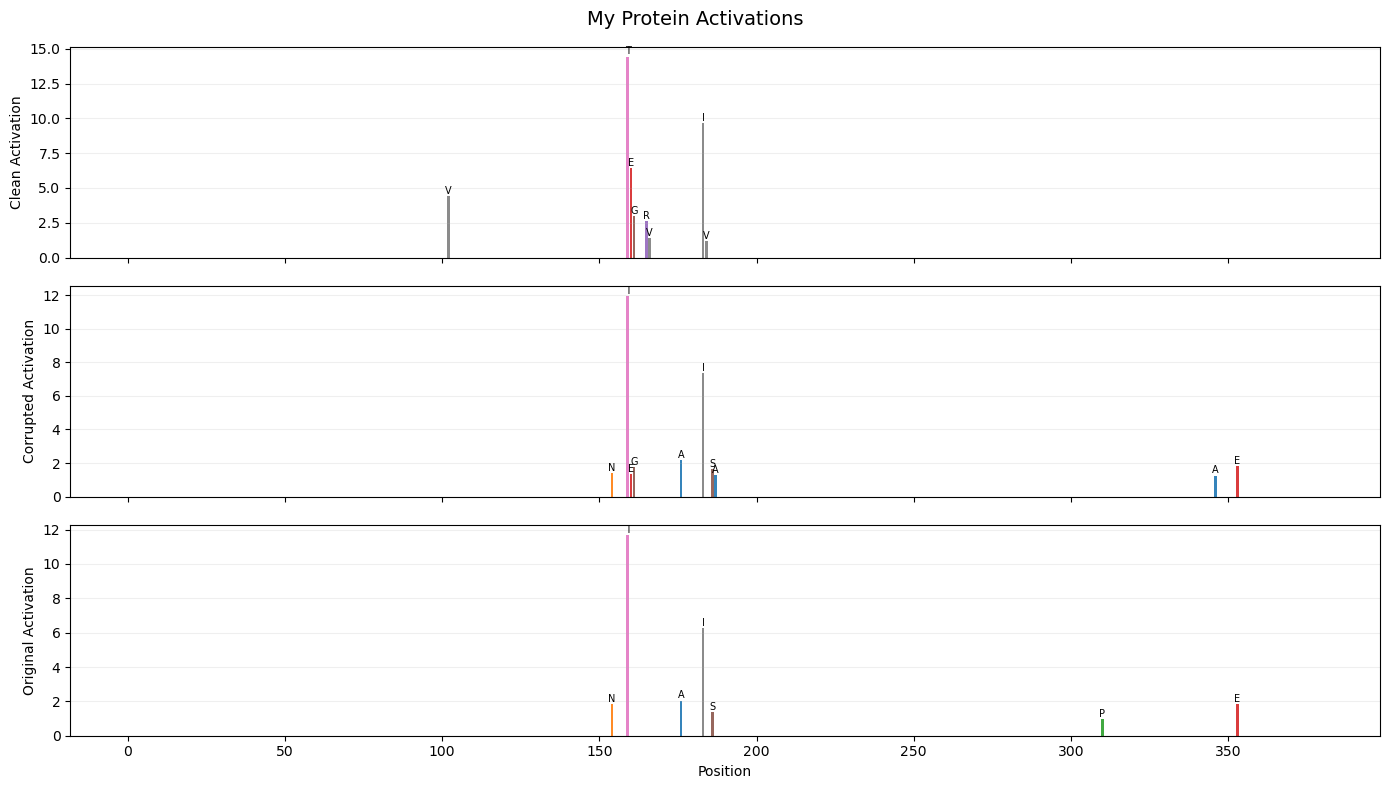

In [69]:
plot_activations_comparison(computed_act_full, computed_act_clean, computed_act_corr, 
                          sequence_letters=uniprot_seq, title="My Protein Activations")


In [73]:
render_sequence_heatmap(seq, computed_act_full[1:-1])

In [74]:
render_sequence_heatmap(seq, computed_act_clean[1:-1])

In [75]:
render_sequence_heatmap(seq, computed_act_corr[1:-1])

In [ ]:
interprot_seq = "MPNPTVAIVGLGALGLVTLKNLREEGFDAVGLDRNDYVGGLWHFEEGNKLTVMRSTLSNGSKQRGCFTDFPFPEDSPDFIPAEGIDRYLKDYAKHFGLLEHCRLRTSFHGARYDEKKQQWRLSLSTPDAPEPHFEWFDKVVFAMGADQIPSRPKIEGIEKFKGHVEHSMSFKNPETLAGKRVMVLGFGNTAADMATELAPIADQVYLAHRHGAIIVPRWVKGKPVDHVRTYRKYVILNLMNRYTPGLWEKTMNSVIGKLVHNTFDLKPEWRFDPAPSITNQRPLVNDELIPSLEKGSIISTHGLARVIDENTVETSDGQRYEVDAILFCTGFTVDYSVVGMDADPCRATTTDWQKSRGFTGRPLPRLYQNIFSLDHPETLAFIGHLSFMNPAFFMFDLASMAVAQLWKDPSGFPSKAEMNKQVDDQHAWVIDLAKKGPVTPSIVKASEWMEWVDRVIGSGLPEHLGYTMKGWNFWMRDRKFCNIMMDGLLSPHAYRVFPGKRKAWPGARDAIIAMNADREARFGPMD"
print(f" seq equal? {interprot_seq == uniprot_seq}")
print(f"seq length: {len(uniprot_seq)}")

In [1]:
import pandas as pd

df = pd.read_csv("../results/domain_correlation_results/topq/annotated_latents_results_og_two.csv")
df.head()

,Case,Layer,Latent_ID,AUC,InterPro ID,InterPro Name,A_in,A_out,Delta_In_Out,L2FC,Bonferroni adj. p-value
0,Top2,4,100,0.956818,IPR008930,Terpenoid cyclases/protein prenyltransferase a...,5.153020,3.690708,1.462312,0.481517,0.036786
1,MetX,4,798,0.951780,IPR018102,"Small ribosomal subunit protein uS11, conserve...",8.440607,2.349753,6.090854,1.844831,0.000033
2,MetX,4,798,0.955919,IPR001971,Small ribosomal subunit protein uS11,8.667236,2.347987,6.319250,1.884142,0.000002
3,MetX,4,798,0.978647,IPR019981,"Small ribosomal subunit protein uS11, bacteria...",9.537890,2.348775,7.189116,2.021756,0.000018
4,MetX,4,798,0.955919,IPR036967,Small ribosomal subunit protein uS11 superfamily,8.667236,2.347987,6.319250,1.884142,0.000002


In [ ]:
latents_of_interest = [(8, 2677), (12, 3035), (12, 3536), (12, 3794), (12, 1256), (12, 2797), (12, 2472), (12, 1082), (8, 488), (12, 2112)]

In [3]:
df[(df['Layer'] == 8) & (df['Latent_ID'] == 2677)]['InterPro ID']


190    IPR020904
191    IPR000073
192    IPR001236
193    IPR004101
194    IPR006151
195    IPR013221
196    IPR020630
197    IPR020631
198    IPR022383
199    IPR023753
200    IPR040131
201    IPR000672
202    IPR001557
203    IPR002218
204    IPR002347
205    IPR015955
206    IPR029058
207    IPR029063
208    IPR036188
209    IPR036291
210    IPR046346
Name: InterPro ID, dtype: object